# 1 · Load MOSTA & map spatial domains

Load the bundled MOSTA-like Stereo-seq subsample, run QC → normalization → Leiden **spatial domains** → marker-based **cell types**, and commit a spatial-domain figure.

> Every notebook calls `check_resources()` first — Stereo-seq sections can be centimeter-scale with millions of bins.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")  # so `_pipeline` is importable when run from cookbook/
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import stereo_fate as sf
from _pipeline import build_result, TARGET_FATE, PROGENITOR
from pathlib import Path
FIG = Path("..") / "figures"; FIG.mkdir(exist_ok=True)
sns.set_context("talk")
# STANDING REQUIREMENT: resource guard first.
sf.check_resources(verbose=True)


stereo-fate resource check
  total RAM      :   62.9 GB
  available RAM  :    4.1 GB
  cpu_count      : 16
  n_jobs (capped): 15


ResourceReport(total_ram_gb=62.87113571166992, available_ram_gb=4.120018005371094, cpu_count=16, n_jobs=15, est_dense_gb=None, fraction_of_available=None, safe=True, recommendation='ok')

In [2]:
adata = build_result()
print(adata)
print('cell types:', sorted(adata.obs['cell_type'].unique()))

stereo-fate resource check
  total RAM      :   62.9 GB
  available RAM  :    4.1 GB
  cpu_count      : 16
  n_jobs (capped): 15
AnnData object with n_obs × n_vars = 2500 × 1225
    obs: 'x', 'y', 'true_cell_type', 'true_commitment', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes', 'domain', 'cell_type', 'dpt_pseudotime', 'fate_axis'
    var: 'is_tf', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dataset', 'diffmap_evals', 'domain', 'hvg', 'iroot', 'liana_res', 'log1p', 'neighbors', 'planted_cardiac_tfs', 'spatial_neighbors', 'stereo_fate'
    obsm: 'X_diffmap', 'X_pca', 'spatial', 'tf_activity', 'ulm_estimate', 'ulm_pvals'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

### Spatial map: domains and marker-based cell types

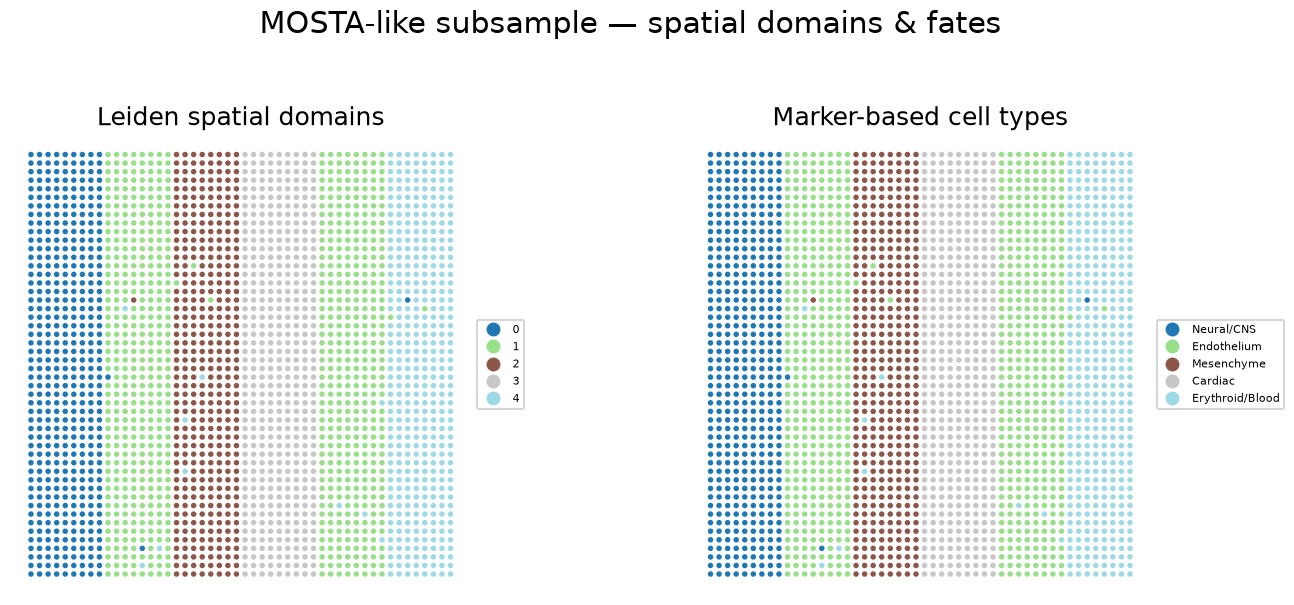

In [3]:
xy = adata.obsm['spatial']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, key, title in [(axes[0],'domain','Leiden spatial domains'),
                       (axes[1],'cell_type','Marker-based cell types')]:
    cats = adata.obs[key].astype('category')
    codes = cats.cat.codes
    sc = ax.scatter(xy[:,0], xy[:,1], c=codes, cmap='tab20', s=6)
    ax.set_title(title); ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
    handles=[plt.Line2D([0],[0],marker='o',ls='',color=plt.cm.tab20(i/ max(1,len(cats.cat.categories)-1)),
             label=c) for i,c in enumerate(cats.cat.categories)]
    ax.legend(handles=handles, fontsize=8, loc='center left', bbox_to_anchor=(1,0.5))
fig.suptitle('MOSTA-like subsample — spatial domains & fates', y=1.02)
fig.tight_layout(); fig.savefig(FIG/'01_spatial_domains.png', dpi=150, bbox_inches='tight')
plt.show()

The Leiden domains form contiguous territories (spatial-graph regularized), and marker scoring labels each as a lineage — including the **Cardiac** territory whose ingredients we'll dissect next.